### Load dataset

In [1]:
from sklearn.model_selection import train_test_split

import torch
from torch import nn, Tensor

from src.models import mk_model
from src.dataset import load_preprocessed_dataset
from src.configs import TrainingConfig, ModelConfig

In [2]:
train_cfg = TrainingConfig()
train_cfg

TrainingConfig(batch_size=1, n_classes=55, n_epochs=30, starting_lr=0.0001, cross_entropy_loss_weight=0.05, dice_loss_weight=0, invariant_d_loss_weight=1, use_labels_weight=True, test_size=0.2, random_state=0)

In [3]:
x_train, y_train, x_test = load_preprocessed_dataset()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=train_cfg.test_size,
    random_state=train_cfg.random_state,
)

In [4]:
model_cfg = ModelConfig()
model_cfg

ModelConfig(channels=(64, 128, 256), strides=(2, 2), kernel_size=3, num_res_units=2, act=('leakyrelu', {'negative_slope': 0.01}), norm='instance', dropout=0.0, bias=True)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cfg = ModelConfig()
model = mk_model(train_cfg, model_cfg)

number of parameters: 1.0M
train


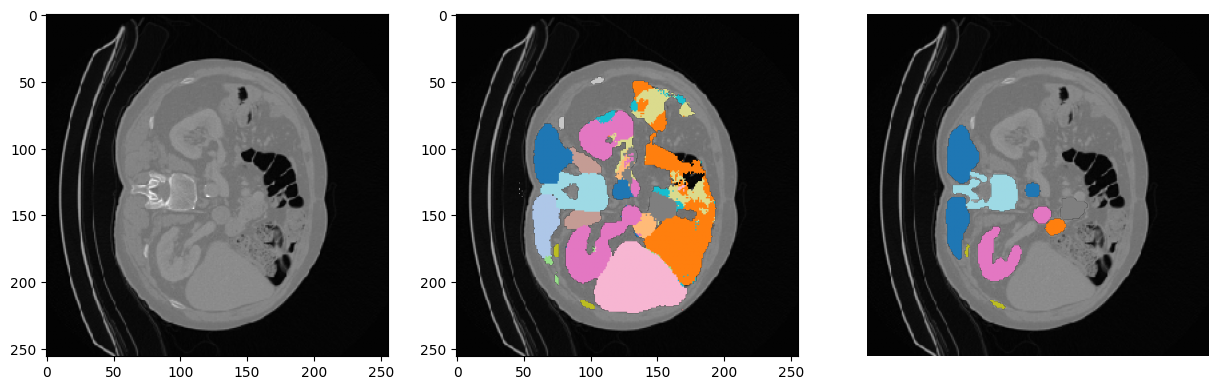

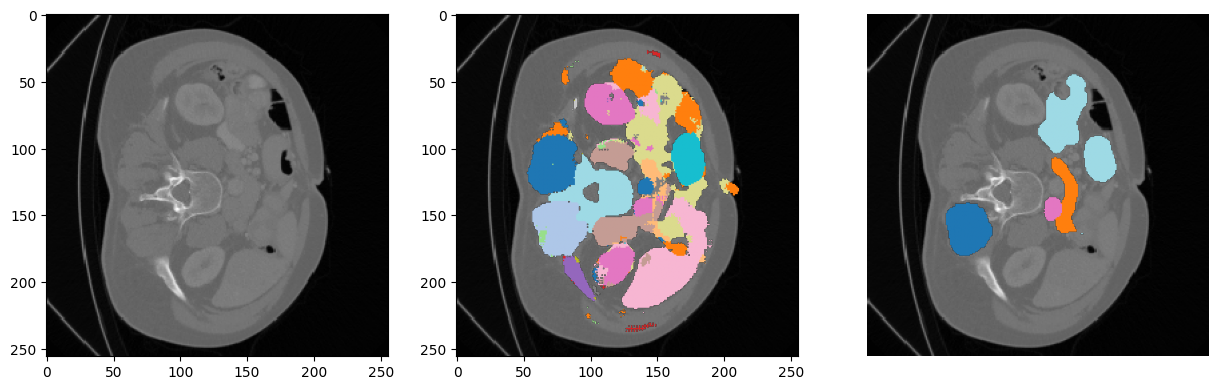

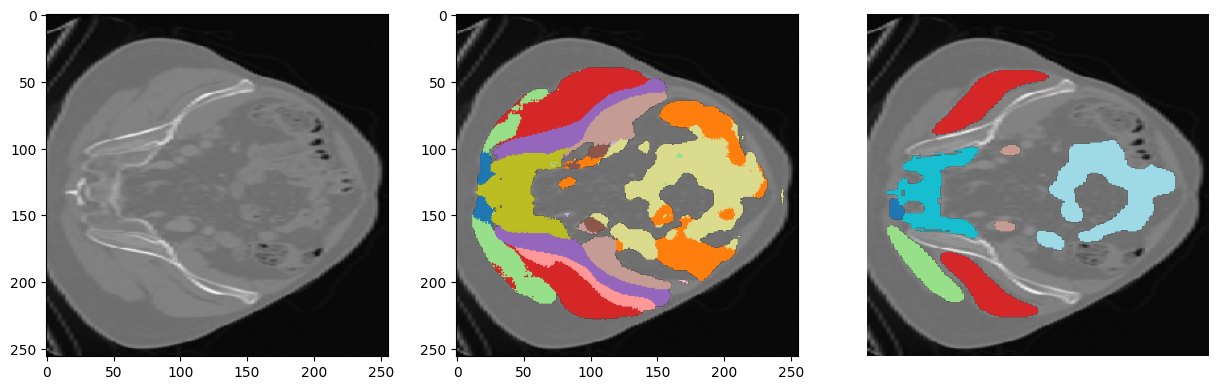

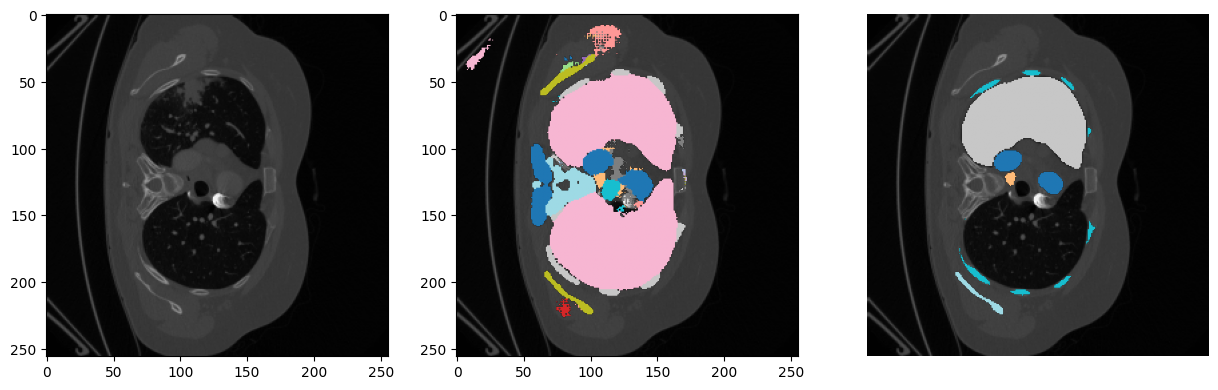

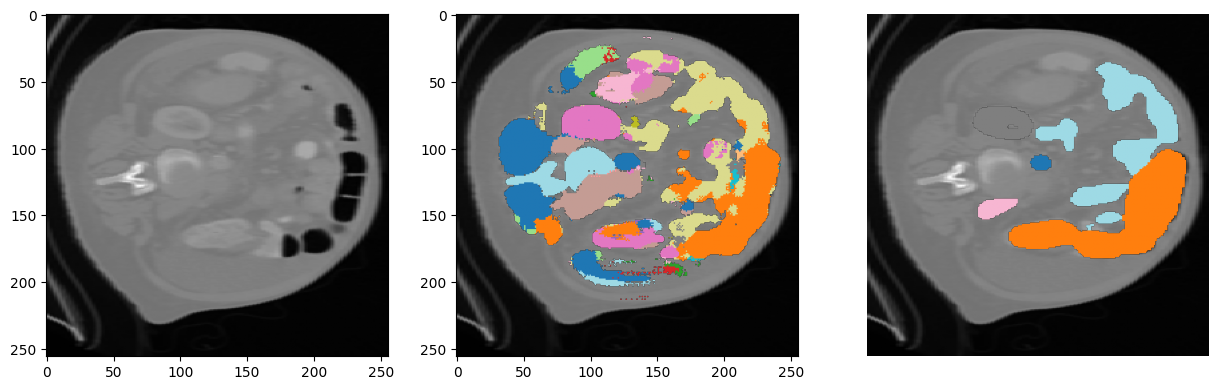

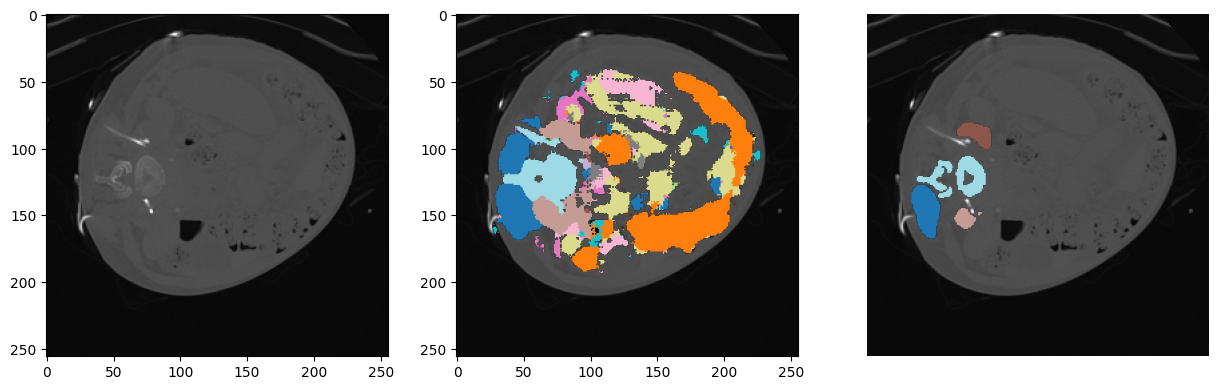

valid


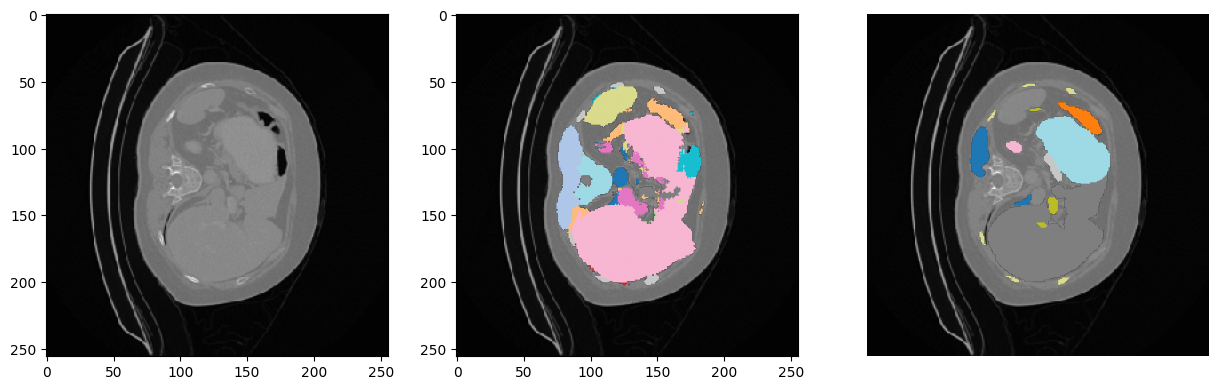

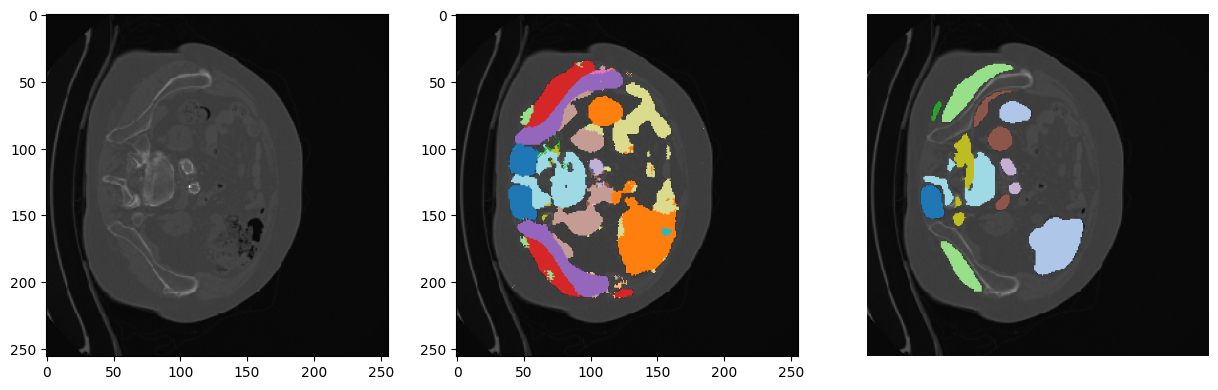

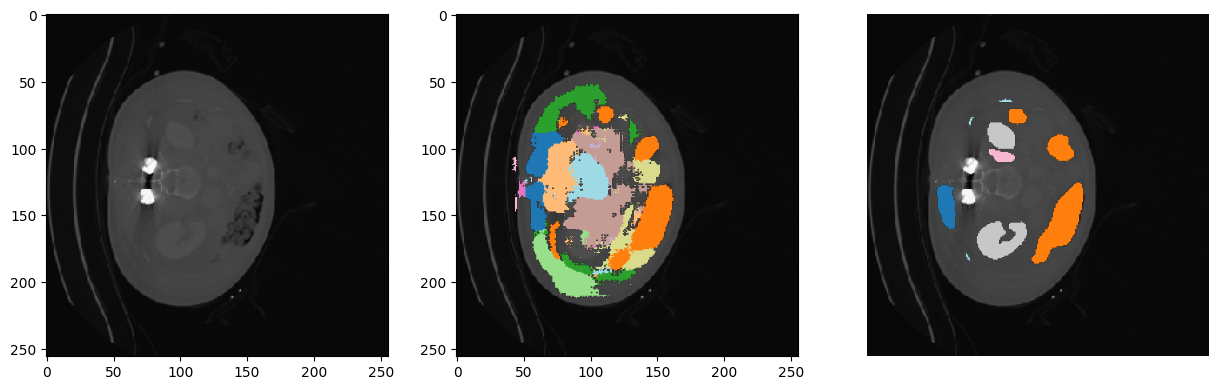

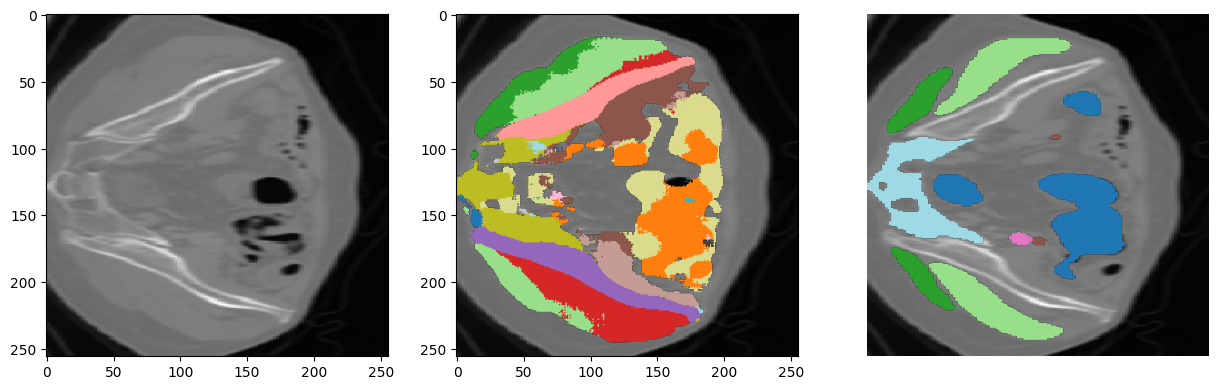

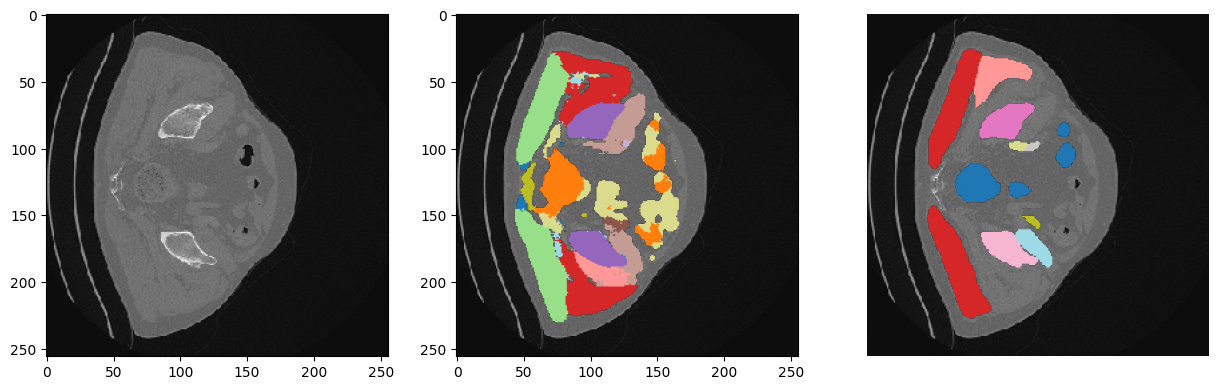

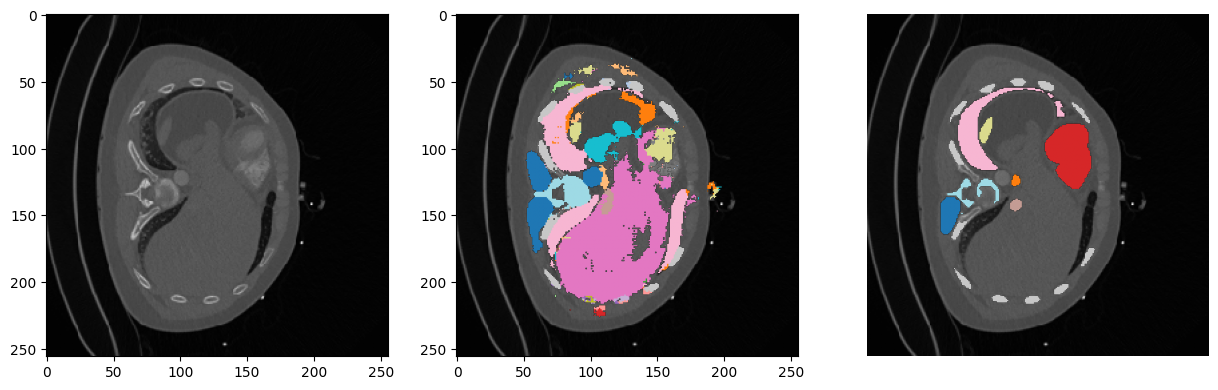

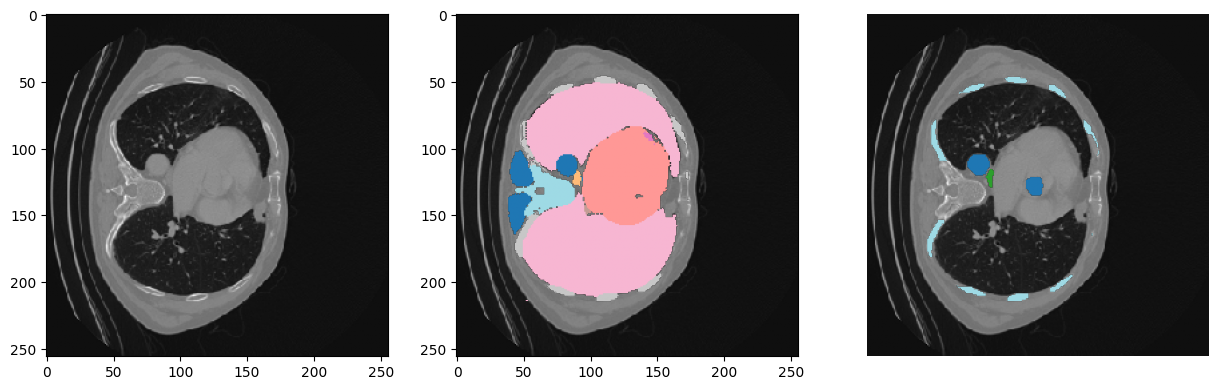

test


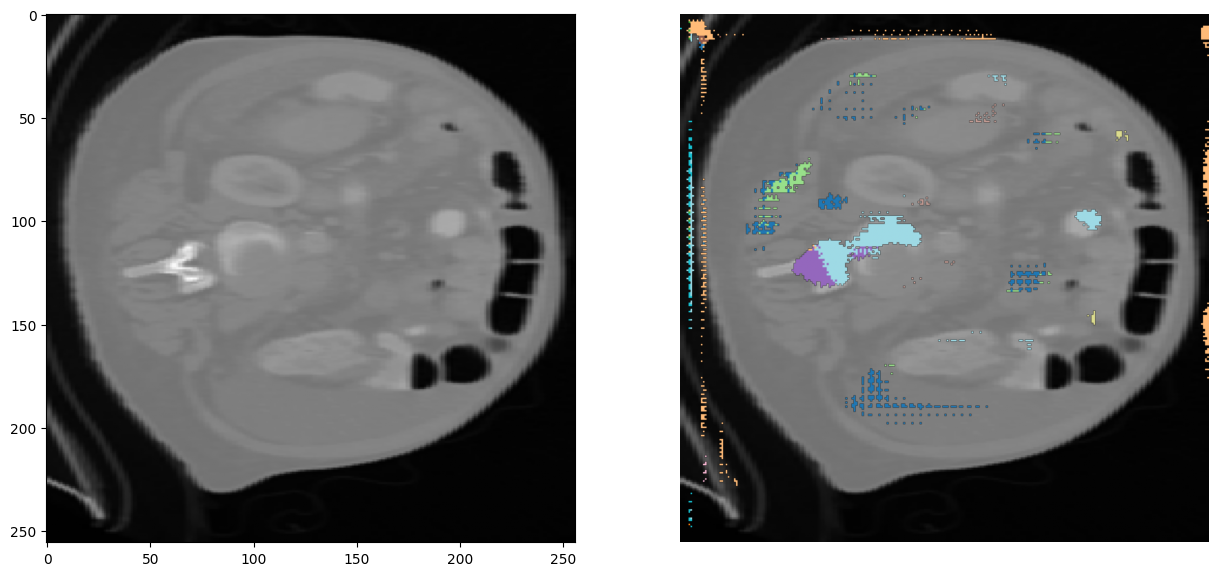

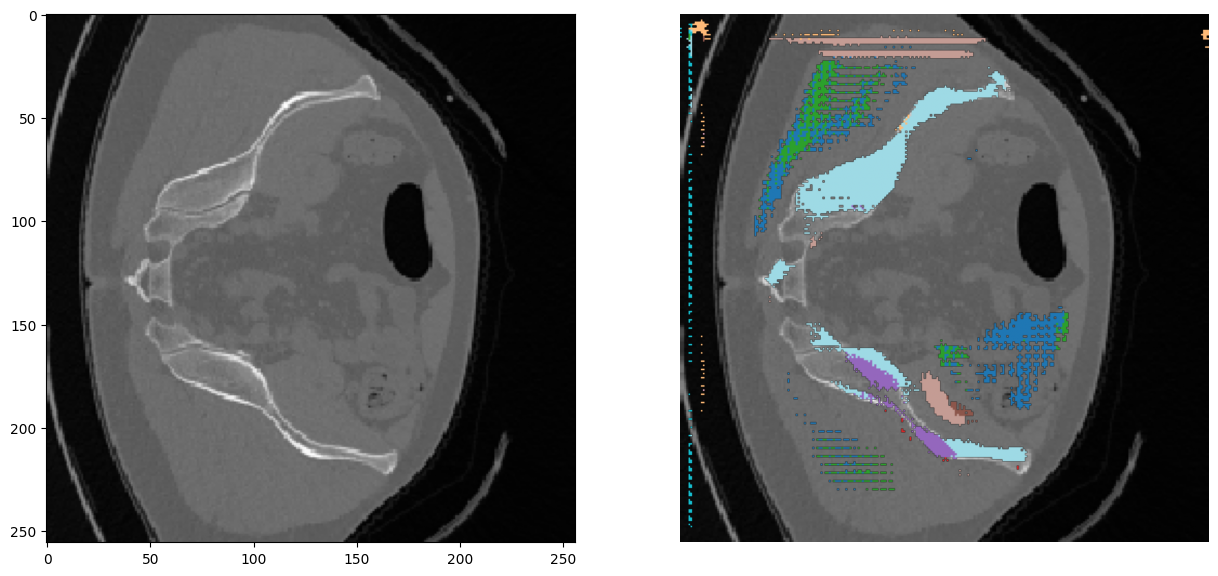

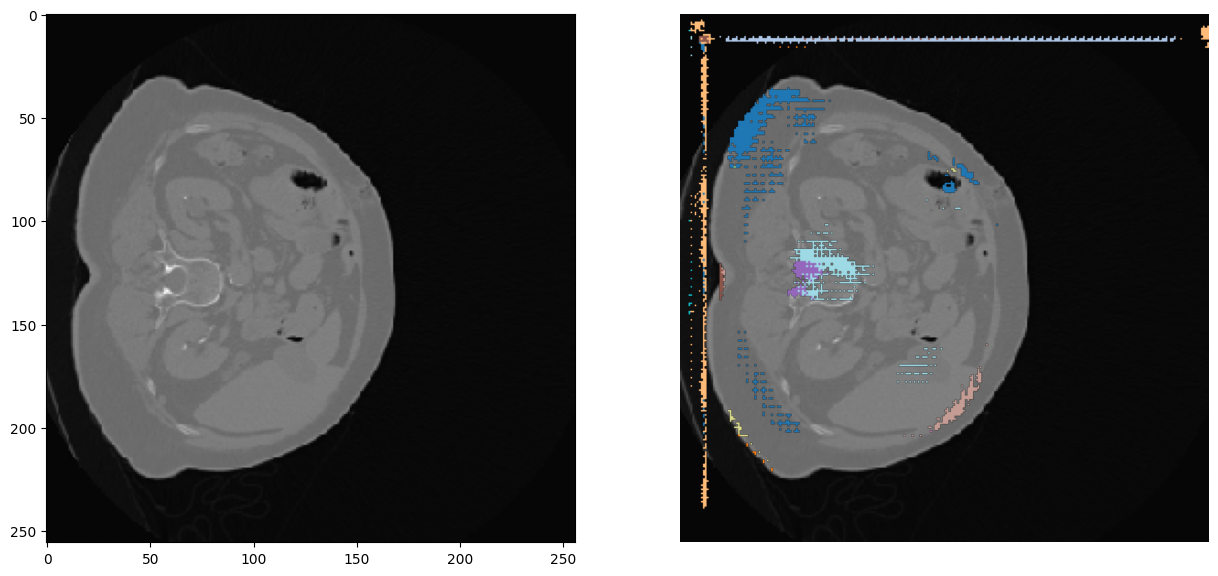

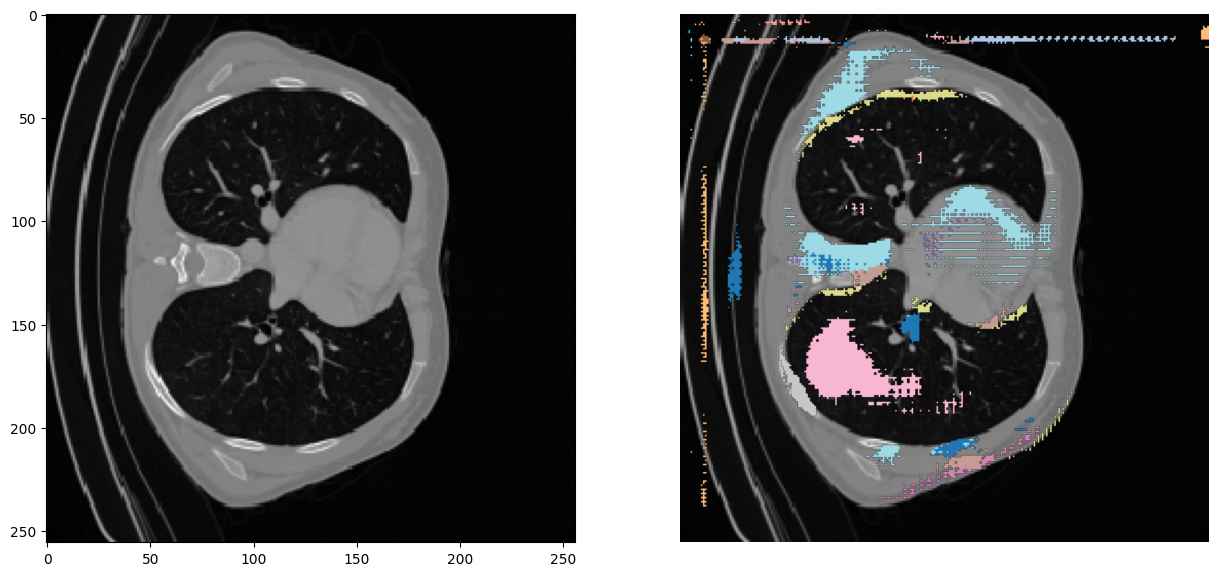

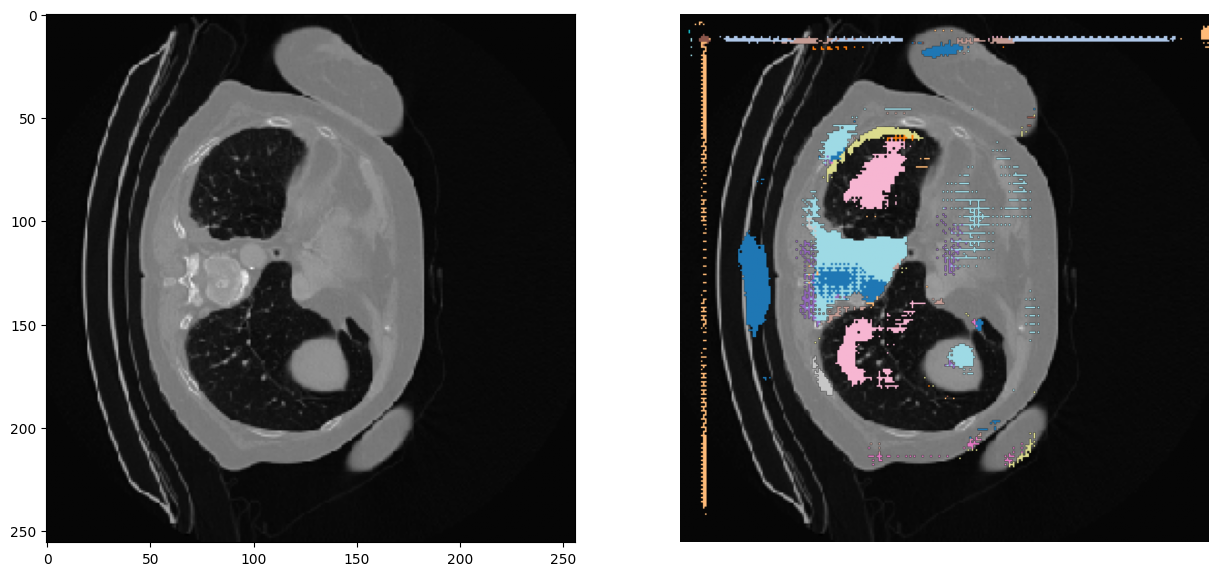

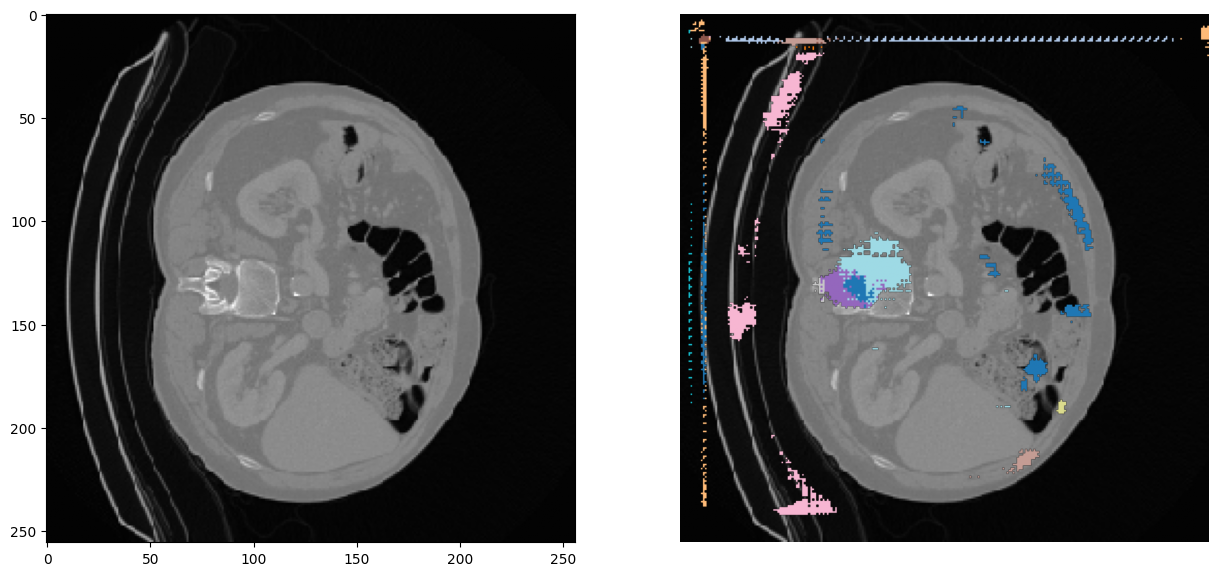

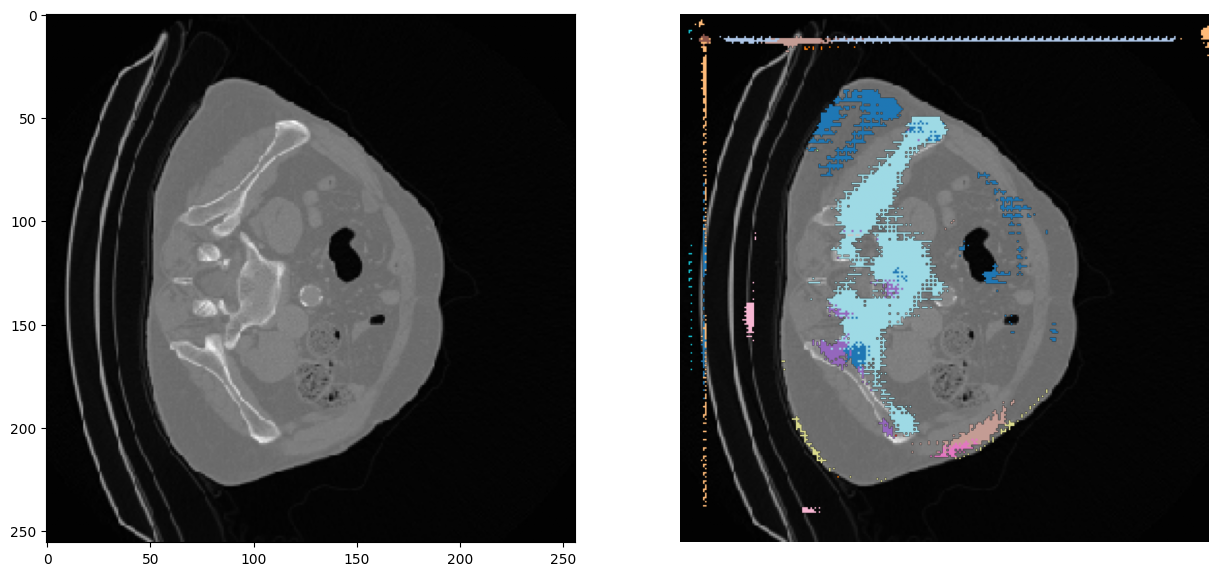

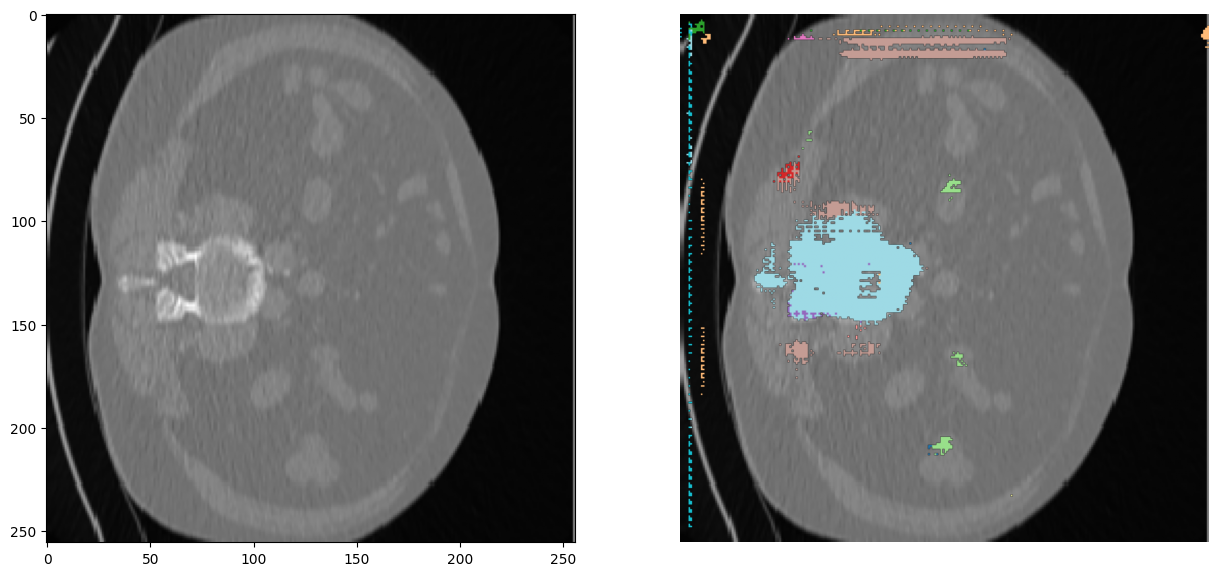

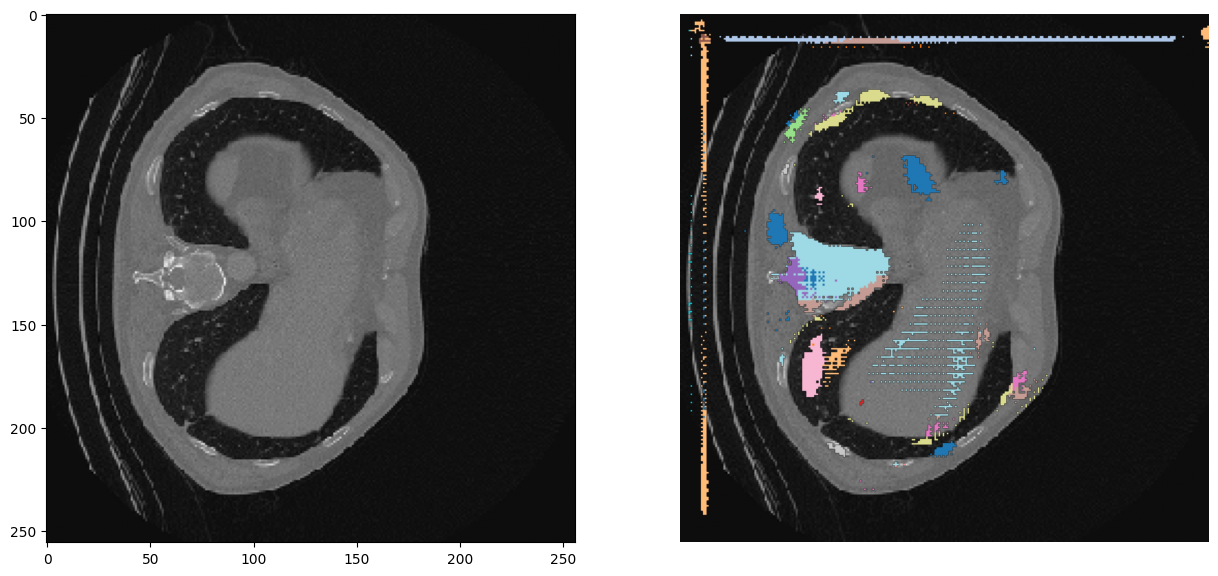

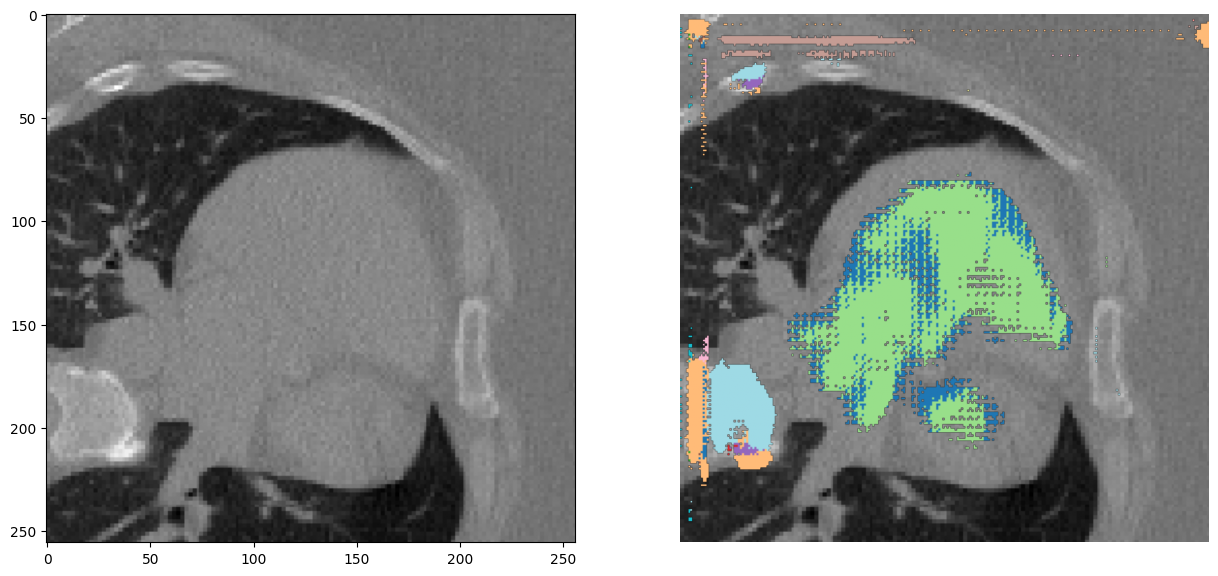

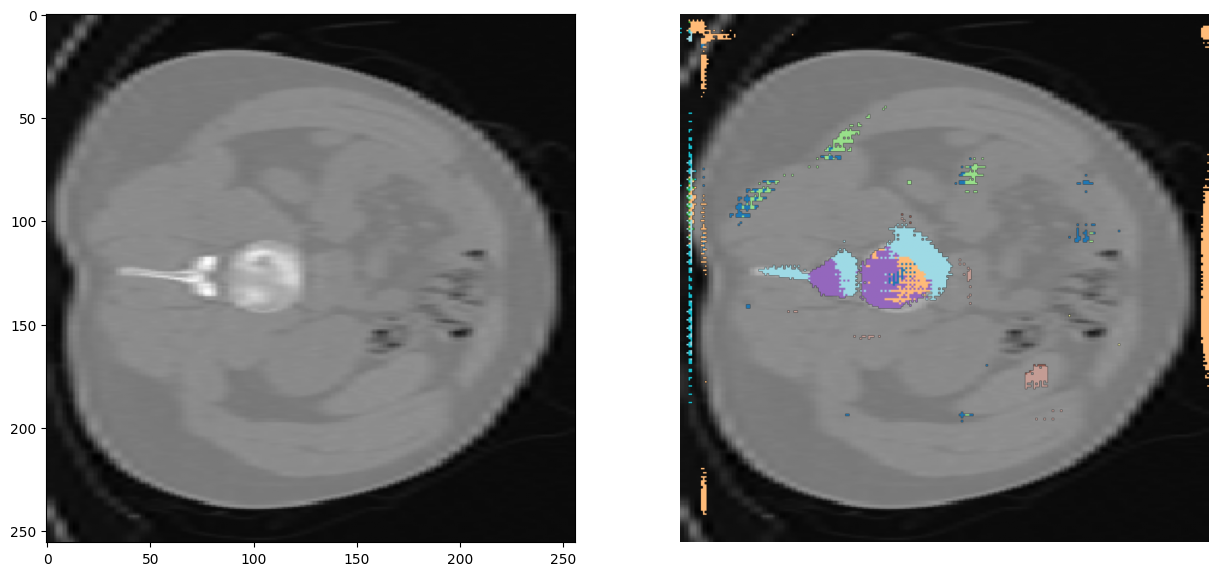

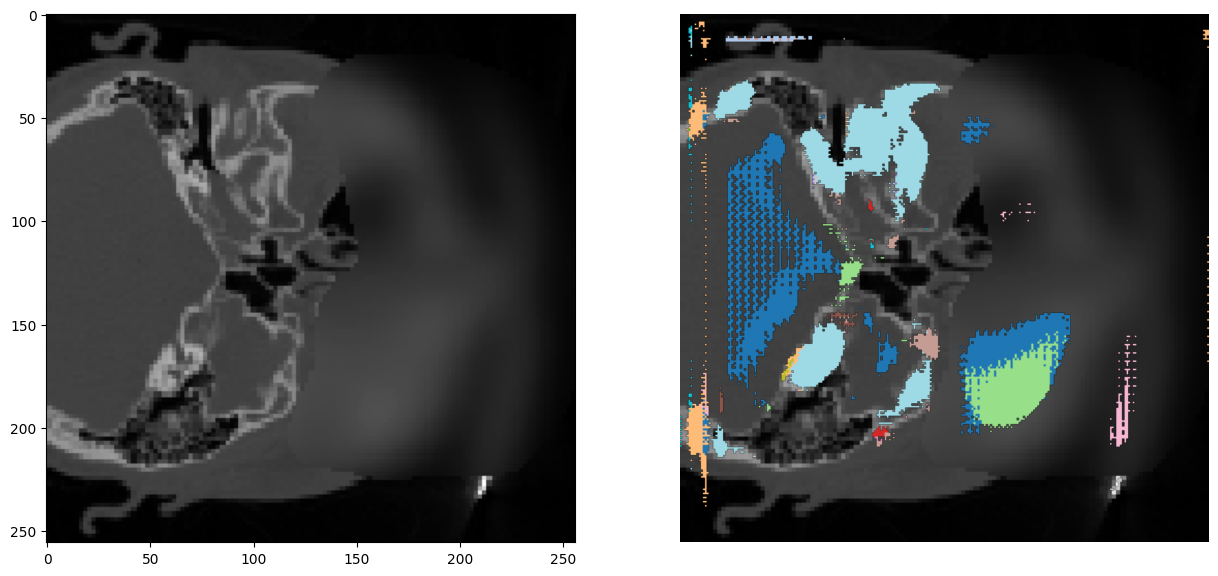

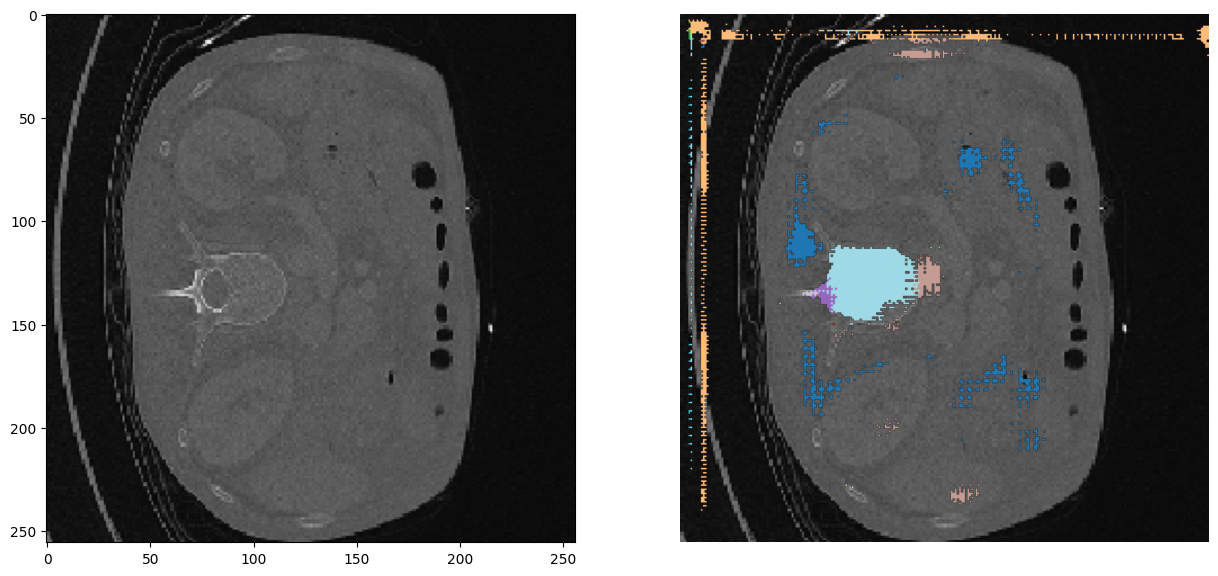

In [12]:
import numpy as np

from src.plotting import plt_pred


model_weights = torch.load(
    f'checkpoints/checkpoint_epoch{29}.pth',
    weights_only=True,
)
model = mk_model(train_cfg, model_cfg).eval()
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print("number of parameters:", str(params // 1e6) + "M")
model.load_state_dict(model_weights)
print("train")
plt_pred(model, 100, x_train, y_train)
plt_pred(model, 120, x_train, y_train)
plt_pred(model, 110, x_train, y_train)
plt_pred(model, 111, x_train, y_train)
plt_pred(model, 112, x_train, y_train)
plt_pred(model, 113, x_train, y_train)
print("valid")
plt_pred(model, 10, x_valid, y_valid)
plt_pred(model, 11, x_valid, y_valid)
plt_pred(model, 12, x_valid, y_valid)
plt_pred(model, 13, x_valid, y_valid)
plt_pred(model, 14, x_valid, y_valid)
plt_pred(model, 15, x_valid, y_valid)
plt_pred(model, 16, x_valid, y_valid)
print("test")
plt_pred(model, 7, x_test)
plt_pred(model, 8, x_test)
plt_pred(model, 81, x_test)
plt_pred(model, 82, x_test)
plt_pred(model, 84, x_test)
plt_pred(model, 85, x_test)
plt_pred(model, 86, x_test)
plt_pred(model, 87, x_test)
plt_pred(model, 100, x_test)
plt_pred(model, 110, x_test)
plt_pred(model, 120, x_test)
plt_pred(model, 130, x_test)
plt_pred(model, 140, x_test)

In [7]:
# from src.dataset import get_data_loaders
# from src.metrics import perm_invariant_dice_loss

# with torch.no_grad():
#     # train_loader, valid_loader = get_data_loaders(x_train, y_train, x_valid, y_valid, 1)
#     b_size = 1
#     x, y_true = x_train[:b_size].to(device), y_train[:b_size].to(device)
#     y_pred = model(x.to(device))
#     model_loss = perm_invariant_dice_loss(y_pred, y_true)
#     from torch.nn.functional import one_hot
#     y_true_one_hot = one_hot(y_true.type(torch.long)).permute(0, 3, 1, 2).type(torch.float32)
#     print(y_true_one_hot.shape)
#     true_loss = perm_invariant_dice_loss(y_true_one_hot, y_true)
#     print("model_loss:", model_loss)
#     print("true_loss:", true_loss)

In [8]:
# import plotly.express as px

# y_mul = torch.arange(y_true_one_hot.shape[1]).reshape(1, -1, 1, 1).to(device)
# y_test = y_mul * y_true_one_hot
# y_true_one_hot_cpu = (
#     y_test
#     .cpu()
#     .sum(dim=1)
#     .numpy()
# )
# y_pred_cpu = (
#     torch.nn.functional.softmax(y_pred, dim=1)
#     .amax(dim=1, keepdim=True)
# ).sum(dim=1).cpu().numpy() * y_true_one_hot_cpu.max()
# print(y_pred_cpu.shape)
# px.imshow(
#     np.concat((y_pred_cpu, y_true_one_hot_cpu)),
#     facet_col=0,
#     # facet_col_wrap=1,
#     color_continuous_scale="rainbow",
# )

### Make submission

In [9]:
from tqdm import tqdm

import numpy as np
import pandas as pd
from torch.utils.data import DataLoader


@torch.no_grad
def mk_submission(model: nn.Module, x_test: Tensor, batch_size: int=16):
    test_loader = DataLoader(x_test, batch_size=batch_size, shuffle=False)
    predictions = []

    for image in tqdm(test_loader) :
        image = image.to(device=device)
        y_pred_logits = model(image)
        pred = torch.argmax(y_pred_logits, dim=1)
        predictions.append(pred.cpu().numpy())

    predictions = np.array(predictions)
    print("n unique values:", len(np.unique(predictions)))
    df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T
    df.index = [f"Pixel {i}" for i in df.index]
    df.columns = [f"{col}.png" for col in df.columns]
    df.to_csv("submission.csv")
# 
# mk_submission(model, x_test)